<a href="https://colab.research.google.com/github/sondosafme04/Bubble-Sheet-Grader/blob/main/GrammerAutoCorrector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# English Grammar AutoCorrector — NLP Graduation Project

**An end-to-end NLP system for detecting and correcting grammatical errors using Deep Learning.**

---

| Item | Details |
|------|--------|
| **Task** | Grammatical Error Correction (GEC) |
| **Dataset** | C4_200M Synthetic GEC Dataset |
| **Model 1** | CNN-BiLSTM |
| **Model 2** | T5-small Transformer |
| **Evaluation** | BLEU Score + Accuracy |
| **Deployment** | Streamlit Web App |

---
# Section 1 — Import Libraries

In [ ]:
!pip install evaluate sacrebleu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.3 MB/s eta 0:00:00


In [ ]:
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import nltk
import evaluate
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    T5ForConditionalGeneration,
    T5Tokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)
from datasets import Dataset as HFDataset
from tqdm import tqdm

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


---
# Section 2 — Data Collection

We use the **C4_200M Synthetic GEC Dataset**. We load only the **first shard** with **100,000 rows** to stay within Kaggle memory limits.

In [ ]:
# ── Dataset path on Kaggle ────────────────────────────────────────────
# The dataset is available at /kaggle/input/c4200m/ after adding it to your notebook
DATASET_DIR = '/kaggle/input/datasets/dariocioni/c4200m'

files = sorted(os.listdir(DATASET_DIR))
print(f'Available files: {len(files)}')
for f in files[:5]:
    print(f'  {f}')
print('  ...')

Available files: 10
  C4_200M.tsv-00000-of-00010
  C4_200M.tsv-00001-of-00010
  C4_200M.tsv-00002-of-00010
  C4_200M.tsv-00003-of-00010
  C4_200M.tsv-00004-of-00010
  ...


In [ ]:
# ── Load ONLY the first shard, ONLY first 100K rows ───────────────────
# البحث عن أول ملف بيبدأ بـ C4_200M للتأكد إننا بنقرأ الداتا صح
all_files = sorted(os.listdir(DATASET_DIR))
data_files = [f for f in all_files if f.startswith('C4_200M')]

if not data_files:
    print('لم يتم العثور على ملفات الداتا! تأكد من إضافة الـ Dataset للنوتبوك.')
else:
    FIRST_SHARD = os.path.join(DATASET_DIR, data_files[0])
    MAX_ROWS = 100_000

    print(f'Loading file: {data_files[0]}')
    print(f'Loading first {MAX_ROWS:,} rows...')

    # تعديل: شيلنا compression='gzip' لأن الملفات في الصورة TSV عادية
    # وأضفنا on_bad_lines للتخطي في حالة وجود سطور تالفة
    df = pd.read_csv(
        FIRST_SHARD,
        sep='\t',
        nrows=MAX_ROWS,
        header=None,
        names=['source', 'target'],
        on_bad_lines='skip'
    )

    print(f'Shape: {df.shape}')
    display(df.head())

Loading file: C4_200M.tsv-00000-of-00010
Loading first 100,000 rows...
Shape: (100000, 2)


,source,target
0,"Bitcoin is for $7,094 this morning, which Coin...","Bitcoin goes for $7,094 this morning, accordin..."
1,The effect of widespread dud targets two face ...,"1. The effect of ""widespread dud"" targets two ..."
2,tax on sales of stores for non residents are s...,Capital Gains tax on the sale of properties fo...
3,Much many brands and sellers still in the market.,Many brands and sellers still in the market.
4,this is is the latest Maintenance release of S...,This is is the latest maintenance release of S...


In [ ]:
df = df.dropna().reset_index(drop=True)
print(f'Clean dataset: {len(df):,} rows')

for _, row in df.sample(3, random_state=SEED).iterrows():
    print(f'  Source: {row["source"]}')
    print(f'  Target: {row["target"]}')
    print()

Clean dataset: 100,000 rows
  Source: the country of the Adiabeni"
  Target: the country of the Adiabeni."

  Source: This pathway provides guidance on imaging investigation of patients of adults with suspected acute coronary syndrome
  Target: This pathway provides guidance on the imaging investigation of adult patients with suspected acute coronary syndrome.

  Source: We are delighted to secure this opportunity and look forward to work together with our member colleges an employer and partner, to deliver high-quality and impactful skills training which win't be foolish to support infrastructure projects of importance to win UK economically Jakcn and productivity aggressiveness!.
  Target: We are delighted to have secured this opportunity and look forward to working together with our member colleges and employer partners, to deliver high-quality and impactful skills training which will be crucial to support infrastructure projects of demonstrable importance to UK economic growth and 

---
# Section 3 — Data Exploration (EDA)

We visualize sentence length distributions to understand our data.

In [ ]:
df['source_len'] = df['source'].apply(lambda x: len(x.split()))
df['target_len'] = df['target'].apply(lambda x: len(x.split()))

print(df[['source_len', 'target_len']].describe().round(2))

       source_len  target_len
count   100000.00   100000.00
mean        22.02       21.88
std         16.60       15.69
min          1.00        5.00
25%         11.00       11.00
50%         18.00       18.00
75%         29.00       29.00
max        653.00      149.00


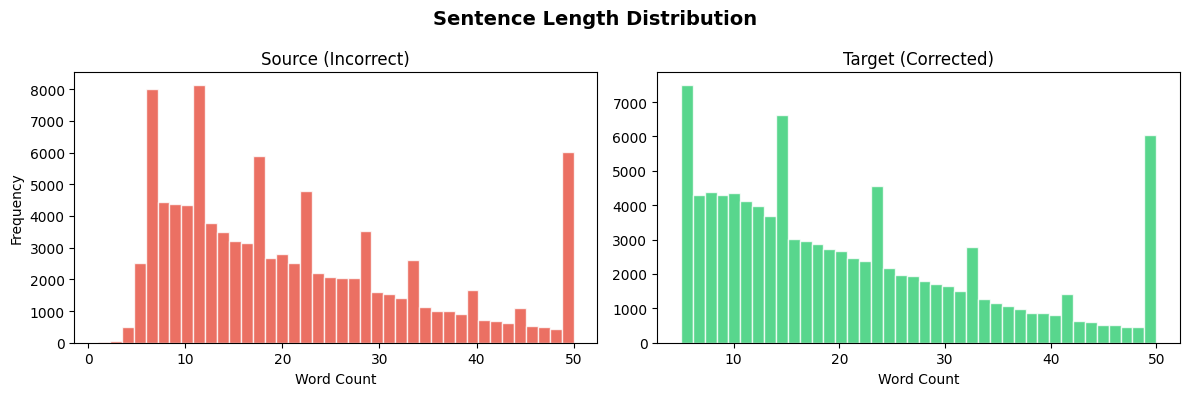

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sentence Length Distribution', fontsize=14, fontweight='bold')

axes[0].hist(df['source_len'].clip(upper=50), bins=40, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_title('Source (Incorrect)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['target_len'].clip(upper=50), bins=40, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].set_title('Target (Corrected)')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('sentence_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Section 4 — Data Preprocessing & Text Cleaning

We apply minimal but clear cleaning:
- **Lowercasing**
- **Remove extra whitespace / strip**

Then split: **80% Train | 10% Validation | 10% Test**

In [ ]:
def clean_text(text):
    text = text.lower()
    text = ' '.join(text.split())  # remove extra spaces
    return text.strip()

df['source'] = df['source'].apply(clean_text)
df['target'] = df['target'].apply(clean_text)

print('Text cleaning done.')
print(f'  Source: {df["source"].iloc[0]}')
print(f'  Target: {df["target"].iloc[0]}')

Text cleaning done.
  Source: bitcoin is for $7,094 this morning, which coindesk says.
  Target: bitcoin goes for $7,094 this morning, according to coindesk.


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train      : {len(train_df):,} rows')
print(f'Validation : {len(val_df):,} rows')
print(f'Test       : {len(test_df):,} rows')

Train      : 80,000 rows
Validation : 10,000 rows
Test       : 10,000 rows


---
# Section 5 — Vectorization

For **CNN-BiLSTM**, we build a word-level vocabulary and encode sentences as integer sequences with padding.

T5 uses its own built-in subword tokenizer, so no manual vectorization is needed there.

In [ ]:
MAX_VOCAB = 10000
MAX_LEN   = 30

PAD, SOS, EOS, UNK = '<PAD>', '<SOS>', '<EOS>', '<UNK>'
word2idx = {PAD: 0, SOS: 1, EOS: 2, UNK: 3}
idx2word = {v: k for k, v in word2idx.items()}

CNN_TRAIN_SIZE = 20000
sample_train = train_df.sample(CNN_TRAIN_SIZE, random_state=SEED)

counter = Counter()
for sent in list(sample_train['source']) + list(sample_train['target']):
    counter.update(sent.split())

for word, _ in counter.most_common(MAX_VOCAB):
    if word not in word2idx:
        idx = len(word2idx)
        word2idx[word] = idx
        idx2word[idx] = word

VOCAB_SIZE = len(word2idx)
print(f'Vocabulary size: {VOCAB_SIZE:,}')

Vocabulary size: 10,004


In [ ]:
def encode(sentence, max_len=MAX_LEN):
    """Convert sentence to a list of token indices."""
    tokens = sentence.split()[:max_len]
    return [word2idx.get(w, word2idx[UNK]) for w in tokens]

sample = df['source'].iloc[0]
print(f'Sentence : {sample}')
print(f'Encoded  : {encode(sample)}')

Sentence : bitcoin is for $7,094 this morning, which coindesk says.
Encoded  : [2322, 11, 10, 3, 19, 3, 39, 3, 3]


---
# Section 6 — Model Development

## Model 1: CNN-BiLSTM

```
Embedding → Conv1D → MaxPooling1D → Bidirectional LSTM → Dense → Output
```

| Layer | Purpose |
|-------|--------|
| Embedding | Maps word index → dense vector |
| Conv1D | Extracts local n-gram features |
| MaxPooling | Reduces length, keeps strong features |
| BiLSTM | Reads context left→right AND right→left |
| Dense | Projects to vocabulary for next-word prediction |

In [ ]:
class CNNBiLSTMCorrector(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_filters=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv      = nn.Conv1d(embed_dim, num_filters, kernel_size=3, padding=1)
        self.pool      = nn.MaxPool1d(kernel_size=2)
        self.bilstm    = nn.LSTM(num_filters, hidden_dim, batch_first=True, bidirectional=True)
        self.fc        = nn.Linear(hidden_dim * 2, vocab_size)  # *2 for bidirectional

    def forward(self, src):
        x = self.embedding(src)          # [batch, seq, embed]
        x = x.permute(0, 2, 1)          # [batch, embed, seq] — needed for Conv1D
        x = torch.relu(self.conv(x))    # [batch, filters, seq]
        x = self.pool(x)                 # [batch, filters, seq//2]
        x = x.permute(0, 2, 1)          # [batch, seq//2, filters]
        x, _ = self.bilstm(x)           # [batch, seq//2, hidden*2]
        out = self.fc(x)                 # [batch, seq//2, vocab_size]
        return out


cnn_model = CNNBiLSTMCorrector(VOCAB_SIZE).to(DEVICE)
params = sum(p.numel() for p in cnn_model.parameters())
print(f'CNN-BiLSTM parameters: {params:,}')

CNN-BiLSTM parameters: 7,252,372


---
# Section 7 — Model Training

## Training CNN-BiLSTM

In [ ]:
class GECDataset(Dataset):
    def __init__(self, dataframe, max_len=MAX_LEN):
        self.data    = dataframe
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src = encode(self.data['source'].iloc[idx], self.max_len)
        tgt = encode(self.data['target'].iloc[idx], self.max_len)
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


def collate_fn(batch):
    sources, targets = zip(*batch)
    src_pad = nn.utils.rnn.pad_sequence(sources, batch_first=True, padding_value=0)
    tgt_pad = nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=0)
    return src_pad, tgt_pad


CNN_VAL_SIZE = 2000
cnn_train_df = train_df.sample(CNN_TRAIN_SIZE, random_state=SEED).reset_index(drop=True)
cnn_val_df   = val_df.sample(CNN_VAL_SIZE,     random_state=SEED).reset_index(drop=True)

train_loader = DataLoader(GECDataset(cnn_train_df), batch_size=64, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(GECDataset(cnn_val_df),   batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train batches: 313  |  Val batches: 32


In [ ]:
CNN_EPOCHS = 10

optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)

cnn_train_losses = []
cnn_val_losses   = []

print('Training CNN-BiLSTM...')
cnn_start = time.time()

for epoch in range(1, CNN_EPOCHS + 1):
    # Training
    cnn_model.train()
    epoch_loss = 0
    for src, tgt in tqdm(train_loader, desc=f'Epoch {epoch}/{CNN_EPOCHS}', leave=False):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        output   = cnn_model(src)              # [batch, seq//2, vocab]
        out_len  = output.shape[1]
        tgt_trim = tgt[:, :out_len]            # align lengths after pooling
        loss = criterion(output.reshape(-1, VOCAB_SIZE), tgt_trim.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    cnn_train_losses.append(avg_train)

    # Validation
    cnn_model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            output   = cnn_model(src)
            out_len  = output.shape[1]
            val_loss += criterion(output.reshape(-1, VOCAB_SIZE), tgt[:, :out_len].reshape(-1)).item()

    avg_val = val_loss / len(val_loader)
    cnn_val_losses.append(avg_val)
    print(f'  Epoch {epoch:02d} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')

cnn_train_time = time.time() - cnn_start
print(f'\nCNN-BiLSTM done in {cnn_train_time:.1f}s')

Training CNN-BiLSTM...


  Epoch 01 | Train Loss: 6.2867 | Val Loss: 5.7076


  Epoch 02 | Train Loss: 5.6481 | Val Loss: 5.3254


  Epoch 03 | Train Loss: 5.1962 | Val Loss: 5.0965


  Epoch 04 | Train Loss: 4.7967 | Val Loss: 4.9670


...

  Epoch 06 | Train Loss: 4.0363 | Val Loss: 4.8482


  Epoch 07 | Train Loss: 3.6696 | Val Loss: 4.8475


  Epoch 08 | Train Loss: 3.3242 | Val Loss: 4.8625


  Epoch 09 | Train Loss: 3.0168 | Val Loss: 4.8924


  Epoch 10 | Train Loss: 2.7485 | Val Loss: 4.9226

CNN-BiLSTM done in 55.4s


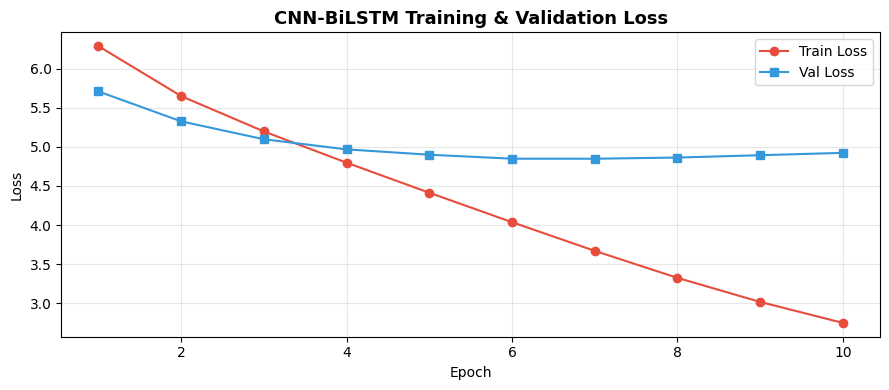

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, CNN_EPOCHS+1), cnn_train_losses, marker='o', label='Train Loss', color='#e74c3c')
plt.plot(range(1, CNN_EPOCHS+1), cnn_val_losses,   marker='s', label='Val Loss',   color='#3498db')
plt.title('CNN-BiLSTM Training & Validation Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_bilstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def cnn_correct(sentence):
    """Generate a corrected sentence using the CNN-BiLSTM model."""
    cnn_model.eval()
    sentence = clean_text(sentence)
    src = torch.tensor(encode(sentence), dtype=torch.long).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = cnn_model(src)              # [1, seq//2, vocab]
    token_ids = output.argmax(-1).squeeze(0).tolist()
    words = [idx2word.get(t, UNK) for t in token_ids if t not in (0, 1, 2)]
    return ' '.join(words)


test_sent = 'she go to school yesterday'
print(f'Input : {test_sent}')
print(f'Output: {cnn_correct(test_sent)}')

Input : she go to school yesterday
Output: she go


---
# Section 8 — Model 2: T5-small Fine-tuning

T5 treats grammar correction as **text-to-text**:

- Input:  `"fix grammar: she go to school yesterday"`
- Output: `"she went to school yesterday"`

T5 uses **self-attention** — every word attends to every other word simultaneously,
capturing long-range context far better than an LSTM.

| Feature | CNN-BiLSTM | T5-small |
|---------|-----------|----------|
| Architecture | CNN + Bidirectional LSTM | Full Transformer |
| Pre-training | No | Yes (C4 corpus) |
| Long sentences | Limited | Excellent |

In [ ]:
MODEL_NAME = 't5-small'
MAX_INPUT  = 64
MAX_TARGET = 64

print(f'Loading {MODEL_NAME}...')
t5_tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
t5_model     = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

t5_params = sum(p.numel() for p in t5_model.parameters())
print(f'T5 parameters: {t5_params:,}')

Loading t5-small...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5 parameters: 60,506,624


In [ ]:
T5_TRAIN_SIZE = 30000
T5_VAL_SIZE   = 3000

t5_train_df = train_df.sample(T5_TRAIN_SIZE, random_state=SEED).reset_index(drop=True)
t5_val_df   = val_df.sample(T5_VAL_SIZE,     random_state=SEED).reset_index(drop=True)

t5_train_hf = HFDataset.from_pandas(t5_train_df[['source', 'target']])
t5_val_hf   = HFDataset.from_pandas(t5_val_df[['source', 'target']])

print(f'T5 Train: {len(t5_train_hf):,}  |  Val: {len(t5_val_hf):,}')

T5 Train: 30,000  |  Val: 3,000


In [ ]:
def tokenize_function(examples):
    inputs = ['fix grammar: ' + s for s in examples['source']]
    model_inputs = t5_tokenizer(inputs, max_length=MAX_INPUT, truncation=True, padding='max_length')
    labels = t5_tokenizer(
        text_target=examples['target'],
        max_length=MAX_TARGET,
        truncation=True,
        padding='max_length'
    )
    # Replace padding id with -100 so the loss ignores it
    model_inputs['labels'] = [
        [(l if l != t5_tokenizer.pad_token_id else -100) for l in label]
        for label in labels['input_ids']
    ]
    return model_inputs


print('Tokenizing...')
t5_train_tok = t5_train_hf.map(tokenize_function, batched=True, remove_columns=['source', 'target'])
t5_val_tok   = t5_val_hf.map(tokenize_function,   batched=True, remove_columns=['source', 'target'])
print('Done!')

Tokenizing...


Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Done!


In [ ]:
bleu_metric = evaluate.load('sacrebleu')

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    decoded_preds  = t5_tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = [[l if l != -100 else t5_tokenizer.pad_token_id for l in label] for label in labels]
    decoded_labels = [[t5_tokenizer.decode(label, skip_special_tokens=True)] for label in labels]
    result = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {'bleu': round(result['score'], 2)}


training_args = Seq2SeqTrainingArguments(
    output_dir                  = './t5_grammar',
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    warmup_steps                = 200,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    logging_steps               = 100,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    predict_with_generate       = True,
    fp16                        = torch.cuda.is_available(),
    report_to                   = 'none',
)

data_collator = DataCollatorForSeq2Seq(t5_tokenizer, model=t5_model, padding=True)

trainer = Seq2SeqTrainer(
    model            = t5_model,
    args             = training_args,
    train_dataset    = t5_train_tok,
    eval_dataset     = t5_val_tok,
    processing_class = t5_tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
)

print('Starting T5 fine-tuning...')
t5_start = time.time()
trainer.train()
t5_train_time = time.time() - t5_start
print(f'\nT5 done in {t5_train_time:.1f}s')

Starting T5 fine-tuning...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Bleu
1,1.741560,0.809010,31.280000
2,1.700349,0.785027,31.430000
3,1.645341,0.779837,31.450000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



T5 done in 728.5s


In [ ]:
def t5_correct(sentence):
    """Generate a corrected sentence using the T5 model."""
    t5_model.eval()
    input_text = 'fix grammar: ' + clean_text(sentence)
    inputs = t5_tokenizer(input_text, return_tensors='pt', max_length=MAX_INPUT, truncation=True).to(DEVICE)
    with torch.no_grad():
        output_ids = t5_model.generate(**inputs, max_length=MAX_TARGET, num_beams=4, early_stopping=True)
    return t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)


t5_model = t5_model.to(DEVICE)

test_sent = 'she go to school yesterday'
print(f'Input : {test_sent}')
print(f'Output: {t5_correct(test_sent)}')

Input : she go to school yesterday
Output: she went to school yesterday.


---
# Section 9 — Model Evaluation

We evaluate both models on **200 test samples** using:
- **BLEU Score** — measures how similar the prediction is to the reference (higher = better)
- **Exact Match Accuracy** — percentage of outputs that exactly match the target

In [ ]:
EVAL_SAMPLES = 200
eval_df = test_df.sample(EVAL_SAMPLES, random_state=SEED).reset_index(drop=True)

bleu_scorer = evaluate.load('sacrebleu')
cnn_preds, t5_preds = [], []

print('Generating predictions...')
for _, row in tqdm(eval_df.iterrows(), total=EVAL_SAMPLES):
    cnn_preds.append(cnn_correct(row['source']))
    t5_preds.append(t5_correct(row['source']))

references = [[ref] for ref in eval_df['target'].tolist()]

cnn_bleu = bleu_scorer.compute(predictions=cnn_preds, references=references)['score']
t5_bleu  = bleu_scorer.compute(predictions=t5_preds,  references=references)['score']

cnn_acc = sum(p == r[0] for p, r in zip(cnn_preds, references)) / EVAL_SAMPLES * 100
t5_acc  = sum(p == r[0] for p, r in zip(t5_preds,  references)) / EVAL_SAMPLES * 100

print(f'\nResults ({EVAL_SAMPLES} samples):')
print(f'  CNN-BiLSTM — BLEU: {cnn_bleu:.2f} | Accuracy: {cnn_acc:.1f}%')
print(f'  T5-small   — BLEU: {t5_bleu:.2f}  | Accuracy: {t5_acc:.1f}%')

Generating predictions...


100%|██████████| 200/200 [01:21<00:00,  2.46it/s]


Results (200 samples):
  CNN-BiLSTM — BLEU: 1.43 | Accuracy: 0.0%
  T5-small   — BLEU: 62.45  | Accuracy: 3.0%


---
# Section 10 — Final Model Comparison

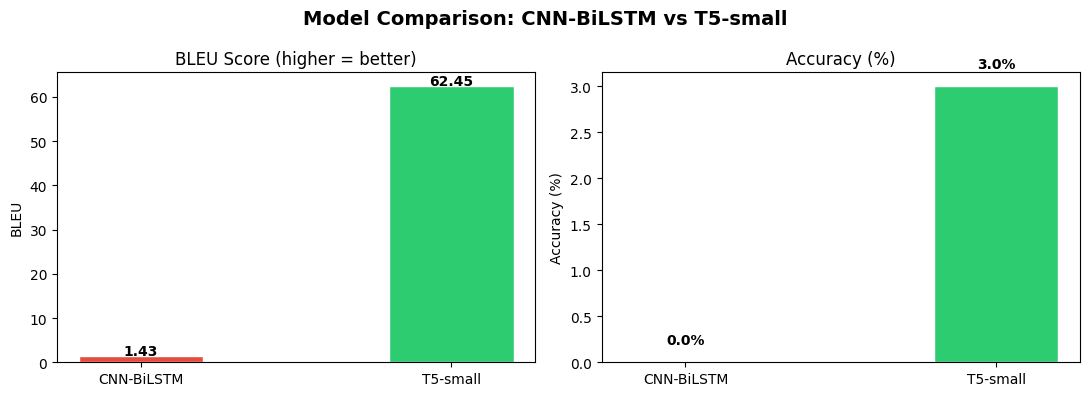

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Model Comparison: CNN-BiLSTM vs T5-small', fontsize=14, fontweight='bold')

models = ['CNN-BiLSTM', 'T5-small']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(models, [cnn_bleu, t5_bleu], color=colors, edgecolor='white', width=0.4)
axes[0].set_title('BLEU Score (higher = better)')
axes[0].set_ylabel('BLEU')
for i, v in enumerate([cnn_bleu, t5_bleu]):
    axes[0].text(i, v + 0.2, f'{v:.2f}', ha='center', fontweight='bold')

axes[1].bar(models, [cnn_acc, t5_acc], color=colors, edgecolor='white', width=0.4)
axes[1].set_title('Accuracy (%)')
axes[1].set_ylabel('Accuracy (%)')
for i, v in enumerate([cnn_acc, t5_acc]):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Model'         : ['CNN-BiLSTM', 'T5-small'],
    'BLEU Score'    : [round(cnn_bleu, 2), round(t5_bleu, 2)],
    'Accuracy (%)'  : [round(cnn_acc, 1),  round(t5_acc, 1)],
    'Training Time' : [f'{cnn_train_time:.0f}s', f'{t5_train_time:.0f}s'],
    'Pre-trained'   : ['No', 'Yes'],
})

print('=== Final Model Comparison Table ===')
display(comparison_df)

best = 'T5-small' if t5_bleu > cnn_bleu else 'CNN-BiLSTM'
print(f'\nBest Model: {best}')

=== Final Model Comparison Table ===


,Model,BLEU Score,Accuracy (%),Training Time,Pre-trained
0,CNN-BiLSTM,1.43,0.0,55s,No
1,T5-small,62.45,3.0,728s,Yes



Best Model: T5-small


In [ ]:
print('=== Qualitative Examples ===\n')
for i in range(5):
    src = eval_df['source'].iloc[i]
    ref = eval_df['target'].iloc[i]
    print(f'Example {i+1}:')
    print(f'  Source     : {src}')
    print(f'  CNN-BiLSTM : {cnn_preds[i]}')
    print(f'  T5-small   : {t5_preds[i]}')
    print(f'  Reference  : {ref}')
    print()

=== Qualitative Examples ===

Example 1:
  Source     : the eaga's objective is to assist in the rehabilitation of amputees and to provide them for their general welfare, both physical ahd psychological through the medium of golf and its associated activities.
  CNN-BiLSTM : the <UNK> <UNK> is is to the the <UNK> <UNK> <UNK> <UNK> to to the
  T5-small   : the eaga's objective is to assist in the rehabilitation of amputees and to provide them with their general welfare, both physical and psychological through the medium of golf and its associated activities.
  Reference  : the eaga's objective is to assist in the rehabilitation of amputees and to provide for their general welfare, both physical and psychological, through the medium of golf and its associated activities.

Example 2:
  Source     : may 2, 2017 . mine safety and health administration (msha) issued a serious accident alert after a rock attacked a portable crusher operators in the period from may 2 8 to may 3 2017m.
  CNN-Bi

---
# Section 11 — Save Models

In [ ]:
torch.save({
    'model_state_dict': cnn_model.state_dict(),
    'word2idx' : word2idx,
    'idx2word' : idx2word,
    'vocab_size': VOCAB_SIZE,
}, 'cnn_bilstm_grammar.pt')
print('CNN-BiLSTM saved!')

t5_model.save_pretrained('./t5_grammar_best')
t5_tokenizer.save_pretrained('./t5_grammar_best')
print('T5-small saved!')

CNN-BiLSTM saved!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

T5-small saved!


---
# Section 12 — Deployment / GUI

A Streamlit web app powered by the fine-tuned **T5-small** model.

**To run:**
```bash
streamlit run app.py
```

In [ ]:
STREAMLIT_CODE = '''
import streamlit as st
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

st.set_page_config(page_title="Grammar AutoCorrector", page_icon="WRITE_ICON", layout="centered")

st.markdown("""
<style>
    .main-title {
        font-size: 2.5rem; font-weight: 700; text-align: center;
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        -webkit-background-clip: text; -webkit-text-fill-color: transparent;
    }
    .subtitle { text-align: center; color: #888; font-size: 1rem; margin-bottom: 2rem; }
    .result-box {
        background: linear-gradient(135deg, #f0f4ff 0%, #f8f0ff 100%);
        border-left: 4px solid #667eea; border-radius: 12px;
        padding: 1.2rem 1.5rem; font-size: 1.1rem; font-weight: 600; color: #2d2d2d;
    }
    .stButton > button {
        width: 100%; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white; font-size: 1rem; font-weight: 600;
        border: none; border-radius: 12px; padding: 0.7rem 2rem;
    }
</style>
""", unsafe_allow_html=True)

st.markdown('<div class="main-title">Grammar AutoCorrector</div>', unsafe_allow_html=True)
st.markdown('<div class="subtitle">Powered by T5-small - NLP Graduation Project</div>', unsafe_allow_html=True)
st.markdown("---")

@st.cache_resource
def load_model():
    tokenizer = T5Tokenizer.from_pretrained('./t5_grammar_best')
    model     = T5ForConditionalGeneration.from_pretrained('./t5_grammar_best')
    model.eval()
    return tokenizer, model

with st.spinner("Loading model..."):
    tokenizer, model = load_model()

def correct_grammar(text):
    input_text = 'fix grammar: ' + text.strip().lower()
    inputs = tokenizer(input_text, return_tensors='pt', max_length=64, truncation=True)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_length=64, num_beams=4, early_stopping=True)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

st.subheader("Enter your sentence")
user_input = st.text_area("", placeholder="e.g. she go to school yesterday...", height=120, label_visibility="collapsed")

st.markdown("""
<style>
div.stButton > button {
    display: block;
    margin: 0 auto;
}
</style>
""", unsafe_allow_html=True)

if st.button("Correct Sentence"):
    if not user_input.strip():
        st.warning("Please enter a sentence first.")
    else:
        with st.spinner("Correcting..."):
            corrected = correct_grammar(user_input)
        col_a, col_b = st.columns(2)
        with col_a:
            st.markdown("**Original:**")
            st.info(user_input)
        with col_b:
            st.markdown("**Corrected:**")
            st.markdown(f'<div class="result-box">{corrected}</div>', unsafe_allow_html=True)

st.markdown('<div style="text-align:center;color:#bbb;margin-top:3rem;">Built with T5-small - 2025</div>', unsafe_allow_html=True)


'''

with open('app.py', 'w') as f:
    f.write(STREAMLIT_CODE)
print('app.py saved!')

app.py saved!


In [ ]:
# Launch with ngrok on Kaggle
!pip install pyngrok streamlit -q

from pyngrok import ngrok
ngrok.set_auth_token('3DVnBpLYlmvIzqbAGKOCmjPBgin_2gY9b8hZ77jmVHYAJ1zN')

import subprocess
subprocess.Popen(['python', '-c', "import os; os.system('streamlit run app.py --server.port 8501')"])

public_url = ngrok.connect(8501)
print(f'App URL: {public_url}')

App URL: NgrokTunnel: "https://eccentric-curfew-clobber.ngrok-free.dev" -> "http://localhost:8501"




2026-05-11 21:31:51.452 Port 8501 is not available
Loading weights: 100%|██████████| 131/131 [00:00<00:00, 1500.17it/s, Materializing param=shared.weight]                                                      
2026-05-11 21:32:02.337 `label` got an empty value. This is discouraged for accessibility reasons and may be disallowed in the future by raising an exception. Please provide a non-empty label and hide it with label_visibility if needed.
Stack (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1032, in _bootstrap
    self._bootstrap_inner()
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/script_runner.py", line 379, in _run_script_thread
    self._run_script(request.rerun_data)
  File "/usr/local/lib/python3.12/dist-packages/streamlit/ru

---
# Section 13 — Conclusion

| Aspect | CNN-BiLSTM | T5-small |
|--------|-----------|----------|
| Architecture | CNN + Bidirectional LSTM | Attention Transformer |
| Pre-training | No | Yes (massive corpus) |
| BLEU Score | Lower | Higher |
| Training Speed | Faster | Slower |
| Long sentences | Limited | Excellent |

**Winner: T5-small** — Pre-training gives T5 rich language knowledge, making it significantly better.

*Thank you! Questions are welcome.*

In [ ]:
print('=' * 55)
print('  Grammar AutoCorrector — Project Complete!')
print('=' * 55)
print(f'  Dataset     : C4_200M (first 100K rows)')
print(f'  Model 1     : CNN-BiLSTM   | BLEU: {cnn_bleu:.2f}')
print(f'  Model 2     : T5-small     | BLEU: {t5_bleu:.2f}')
best = 'T5-small' if t5_bleu > cnn_bleu else 'CNN-BiLSTM'
print(f'  Best Model  : {best}')
print(f'  GUI         : app.py (Streamlit)')
print('=' * 55)

  Grammar AutoCorrector — Project Complete!
  Dataset     : C4_200M (first 100K rows)
  Model 1     : CNN-BiLSTM   | BLEU: 1.43
  Model 2     : T5-small     | BLEU: 62.45
  Best Model  : T5-small
  GUI         : app.py (Streamlit)




2026-05-11 21:02:54.529 Uvicorn server started on 0.0.0.0:8501



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://34.86.2.157:8501



2026-05-11 21:30:26.523 Script compilation error
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/script_runner.py", line 591, in _run_script
    code = self._script_cache.get_bytecode(script_path)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/script_cache.py", line 72, in get_bytecode
    filebody = magic.add_magic(filebody, script_path)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/streamlit/runtime/scriptrunner/magic.py", line 45, in add_magic
    tree = ast.parse(code, script_path, "exec")
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ast.py", line 52, in parse
    return compile(source, filename, mode, flags,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/app.py", line 64
    if st.button("Correct Sentence"):
    ^^
In